# **Project Name - YES Bank Stock Closing Price Prediction**

##### **Project Type**    - Regression



##### **Contribution**    - Individual
##### **Name** -Nandini Dhole


# **Project Summary -**

The YES Bank Stock Closing Price Prediction project focuses on analyzing historical stock market data and developing a machine learning regression model to predict the monthly closing price of YES Bank stock. Stock price prediction is a challenging financial analytics problem because market prices are influenced by multiple factors and may change significantly over time. Accurate analysis of historical stock data can help identify important patterns, price movements, and relationships between different stock price variables.

The dataset used in this project contains historical monthly stock price information for YES Bank. The major variables available in the dataset are Date, Open, High, Low, and Close. The Close variable represents the monthly closing price of the stock and is considered the target variable for prediction. The remaining stock price variables and engineered temporal features are used as independent variables for developing the machine learning models.

The project begins with exploratory data analysis and data preprocessing to understand the structure and quality of the dataset. The dataset is examined for missing values, duplicate records, incorrect data types, and potential outliers. The Date column is converted into datetime format and temporal features such as Year and Month are extracted to provide additional information about stock price movements over time. Additional features such as Price Range and Open-Close Difference are also analyzed to better understand market volatility and price movement.

Data visualization techniques are used to explore the historical behaviour of YES Bank stock prices. Different charts and plots are created to analyze closing price trends, distributions of stock variables, relationships between opening and closing prices, price ranges, yearly trends, and correlations among numerical variables. These visualizations provide important insights into stock price behaviour and help identify the variables that are strongly associated with the closing price.

After data preprocessing and feature engineering, the dataset is divided chronologically into training and testing datasets using an 80:20 ratio. Chronological splitting is used because stock price data is time-dependent and random splitting may introduce data leakage by allowing future observations to influence the training process. Feature scaling is performed using StandardScaler for regression models that are sensitive to feature magnitude.

Three machine learning regression models are developed and evaluated in this project: Linear Regression, Ridge Regression, and Random Forest Regressor. The performance of these models is evaluated using Mean Absolute Error, Root Mean Squared Error, and R² Score. Linear Regression achieved an R² Score of approximately 0.9843, while the tuned Ridge Regression model achieved an R² Score of approximately 0.9844. The Random Forest Regressor achieved an R² Score of approximately 0.9654.

Based on the evaluation results, the tuned Ridge Regression model is selected as the final prediction model. Although Linear Regression achieved a slightly lower Mean Absolute Error, Ridge Regression provides L2 regularization, which helps control large coefficients and improves model stability. Feature coefficient analysis indicates that High, Low, and Open are the most influential variables in predicting the stock closing price.

Finally, the best-performing Ridge Regression model is saved using Joblib and successfully loaded again to perform predictions on unseen test data as a sanity check. The developed project demonstrates an end-to-end machine learning workflow including data understanding, exploratory data analysis, preprocessing, feature engineering, model development, hyperparameter tuning, model evaluation, model explainability, and model serialization. The project can be further extended by incorporating additional financial indicators, market sentiment data, and advanced time-series or deep learning models for more comprehensive stock market analysis.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Problem Statement.**  
The stock market is highly dynamic, and stock prices are influenced by various financial, economic, and market-related factors. YES Bank has experienced significant fluctuations in its stock prices over the years, particularly after 2018 due to financial and regulatory challenges.

The objective of this project is to analyze the historical monthly stock price data of YES Bank and develop supervised machine learning regression models to predict the closing stock price. The dataset contains monthly Date, Open, High, Low, and Close price information.

The project focuses on understanding stock price patterns through exploratory data analysis, examining the relationships among the Open, High, Low, and Close prices, performing suitable data preprocessing and feature engineering, and implementing multiple regression algorithms. The performance of the models will be evaluated using appropriate regression metrics to identify the most effective model for predicting the closing price of YES Bank stock.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import required libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, ttest_rel

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [2]:
# Load Dataset

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ML_Project/data_YesBank_StockPrices.csv')

print("Dataset loaded successfully.")

Mounted at /content/drive
Dataset loaded successfully.


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Display the number of rows and columns in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 185
Number of columns: 5


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Duplicate values count :{duplicate_count}")

Duplicate values count :0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


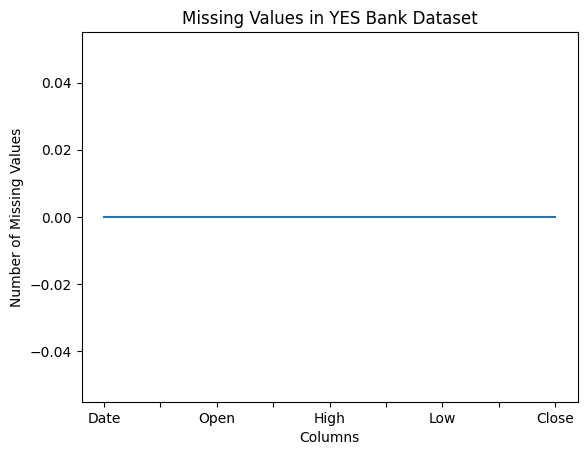

In [8]:
# Visualizing the missing values
missing_values = df.isnull().sum()

missing_values.plot(kind='line')

plt.title('Missing Values in YES Bank Dataset')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.show()

### What did you know about your dataset?

1.   Dataset : 185 rows, 5 columns tracking historical monthly stock prices for YES Bank
2.   Features : Date (stored as object type), Open, High, and Low (all numerical variables).


1.   Target : Close price (numerical variable for regression modeling).
2.   Data Quality : Zero missing values and zero duplicate rows.


1.   Objective: Predict the monthly Close price using the other available input features.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [10]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

The dataset contains the following variables:

* **Date:** Represents the month and year for which the YES Bank stock price is recorded.

* **Open:** Represents the opening price of YES Bank stock for the corresponding month.

* **High:** Represents the highest price reached by the stock during the corresponding month.

* **Low:** Represents the lowest price reached by the stock during the corresponding month.

* **Close:** Represents the closing price of YES Bank stock for the corresponding month. It is the target variable that will be predicted using regression models.

### Check Unique Values for each variable.

Number of unique values in each variable:
Date     185
Open     183
High     184
Low      183
Close    185
dtype: int64


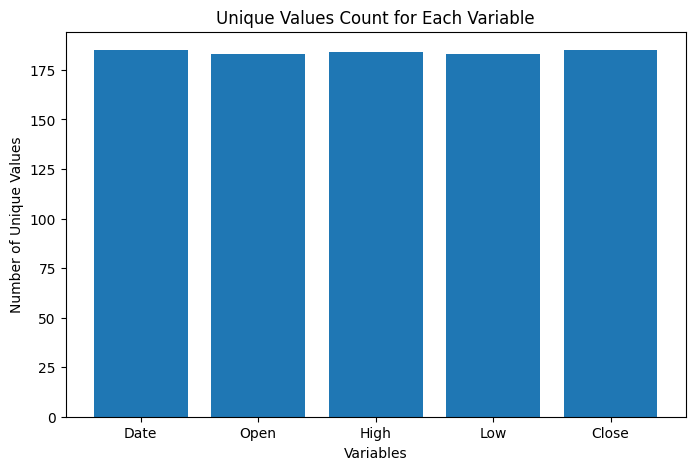

In [11]:
# Check Unique Values for each variable.
# Visualize unique value count for each variable
unique_counts = df.nunique()

print("Number of unique values in each variable:")
print(unique_counts)

# Visualize unique value counts
plt.figure(figsize=(8, 5))
plt.bar(unique_counts.index, unique_counts.values)

plt.xlabel('Variables')
plt.ylabel('Number of Unique Values')
plt.title('Unique Values Count for Each Variable')

plt.show()

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Sort dataset chronologically
df = df.sort_values(by='Date').reset_index(drop=True)

# Verify the updated dataset
print("Updated Data Types:")
print(df.dtypes)

print("\nFirst 5 Rows After Data Wrangling:")
df.head()

Updated Data Types:
Date     datetime64[ns]
Open            float64
High            float64
Low             float64
Close           float64
dtype: object

First 5 Rows After Data Wrangling:


,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


### What all manipulations have you done and insights you found?

1.   Date Formatting: Converted Date from object to datetime format for proper time-based analysis.
2.   Chronological Sorting: Sorted the dataset by Date and reset the index for sequential order.


1.   Data Integrity Verified: Reconfirmed zero missing values and zero duplicate records; no cleaning was required.
2.   EDA Readiness: Dataset is structured with numerical price variables (Open, High, Low, Close) and a datetime index.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

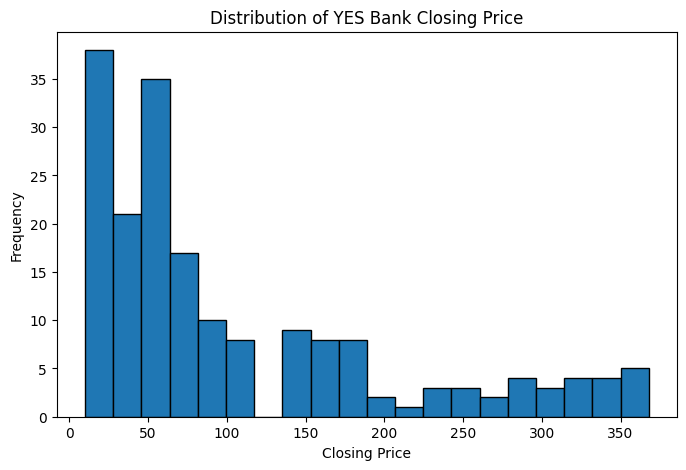

In [13]:
# Chart - 1 visualization code
# Chart 1: Distribution of Closing Price

plt.figure(figsize=(8, 5))

plt.hist(df['Close'], bins=20, edgecolor='black')

plt.title('Distribution of YES Bank Closing Price')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to understand the frequency distribution of the closing price. It helps identify the concentration, spread, and overall distribution pattern of the target variable Close.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how the closing prices of YES Bank are distributed across different price ranges. Most observations are concentrated within certain price intervals, while fewer observations are present at higher price levels. This indicates variation in the stock closing price over the observed period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the distribution of closing prices helps investors and financial analysts identify the common trading price range of the stock. Higher or extreme closing prices may represent periods of strong market performance, while concentration in lower price ranges may indicate periods of weak performance or negative market sentiment. This information is also useful while preparing the target variable for regression modelling.

#### Chart - 2

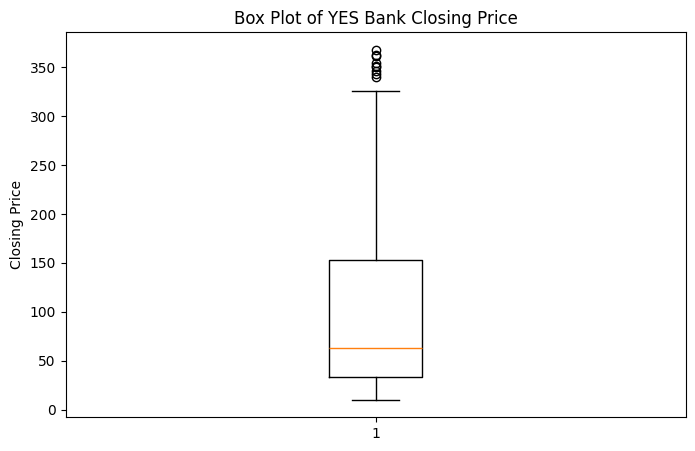

In [14]:
# Chart - 2 visualization code
# Chart 2: Box Plot of Closing Price

plt.figure(figsize=(8, 5))

plt.boxplot(df['Close'])

plt.title('Box Plot of YES Bank Closing Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected to examine the spread of closing prices and identify potential outliers. It clearly represents the median, quartiles, and extreme values present in the Close variable.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows the variation in YES Bank closing prices and highlights extreme price observations. The presence of values outside the normal price range indicates periods when the stock experienced significant price movements.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, identifying extreme stock prices is important for financial risk analysis and machine learning model development. High-price outliers may represent periods of strong market growth, whereas unusually low prices may indicate financial stress or negative market conditions. These observations should be carefully analysed rather than directly removed because they may represent genuine stock market behaviour.

#### Chart - 3

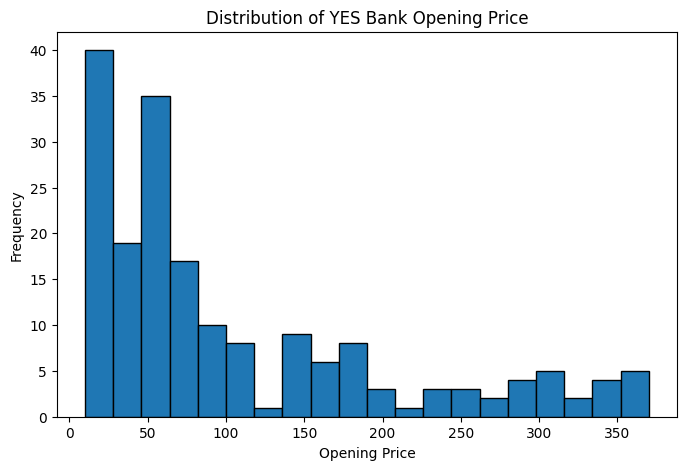

In [15]:
# Chart - 3 visualization code
# Chart 3: Distribution of Opening Price

plt.figure(figsize=(8, 5))

plt.hist(df['Open'], bins=20, edgecolor='black')

plt.title('Distribution of YES Bank Opening Price')
plt.xlabel('Opening Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to analyse the distribution of the opening price. It helps understand the frequency of different opening price ranges and the overall spread of the Open variable.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that YES Bank opening prices vary across different price ranges. A higher concentration of observations in specific price intervals indicates the price levels at which the stock commonly opened during the observed period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, analysing opening price distribution helps investors understand the historical starting price behaviour of the stock. Higher opening prices may indicate positive market sentiment, while lower opening price ranges can reflect weak investor confidence or negative market conditions. The opening price may also provide useful predictive information for estimating the closing price.

#### Chart - 4

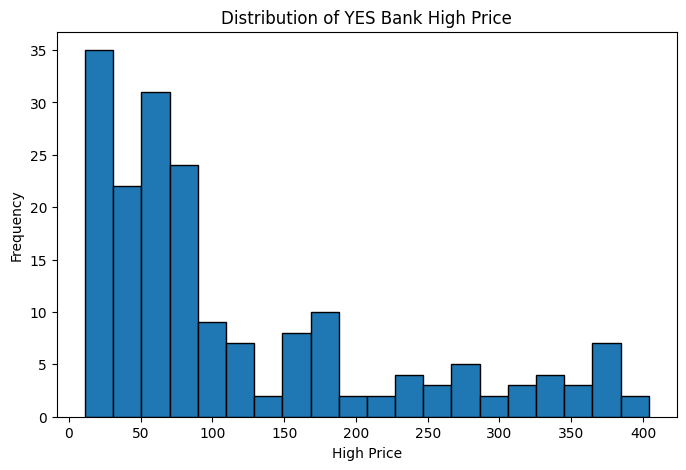

In [16]:
# Chart - 4 visualization code
# Chart 4: Distribution of High Price

plt.figure(figsize=(8, 5))

plt.hist(df['High'], bins=20, edgecolor='black')

plt.title('Distribution of YES Bank High Price')
plt.xlabel('High Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to understand the distribution of the highest stock prices recorded during each month. It helps analyse the frequency and spread of the High variable.

##### 2. What is/are the insight(s) found from the chart?

The chart displays the price ranges in which YES Bank frequently reached its monthly highest price. Fewer observations at extreme high-price levels indicate that very high stock prices occurred during limited periods.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, analysing high-price distribution helps identify periods of strong stock performance and potential bullish market behaviour. Higher price levels can indicate positive investor sentiment. However, extreme high prices followed by significant declines may indicate high volatility and increased investment risk.

#### Chart - 5

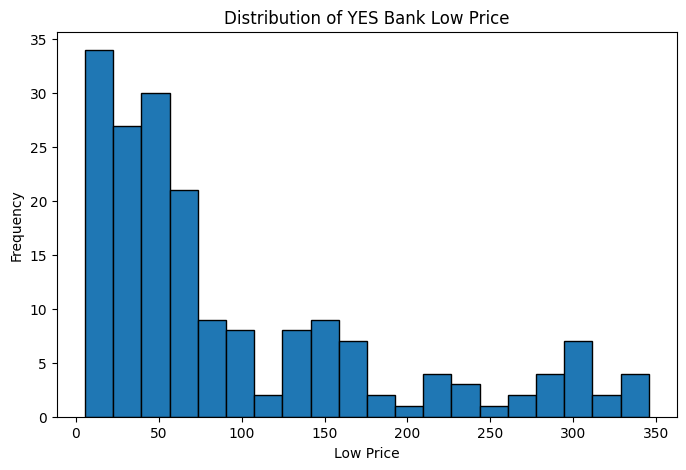

In [17]:
# Chart - 5 visualization code
# Chart 5: Distribution of Low Price

plt.figure(figsize=(8, 5))

plt.hist(df['Low'], bins=20, edgecolor='black')

plt.title('Distribution of YES Bank Low Price')
plt.xlabel('Low Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to analyse the distribution of the lowest stock prices recorded during each month. It helps understand the frequency, concentration, and spread of the Low variable.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the different price ranges in which YES Bank reached its monthly lowest price. The distribution helps identify common lower-price levels and periods of extreme stock price decline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding low-price behaviour helps investors and analysts assess the downside risk associated with the stock. Frequent observations at lower price levels may indicate weak market performance, while extreme low prices can represent periods of financial stress or negative investor sentiment. This information can support risk assessment and stock price prediction.

#### Chart - 6

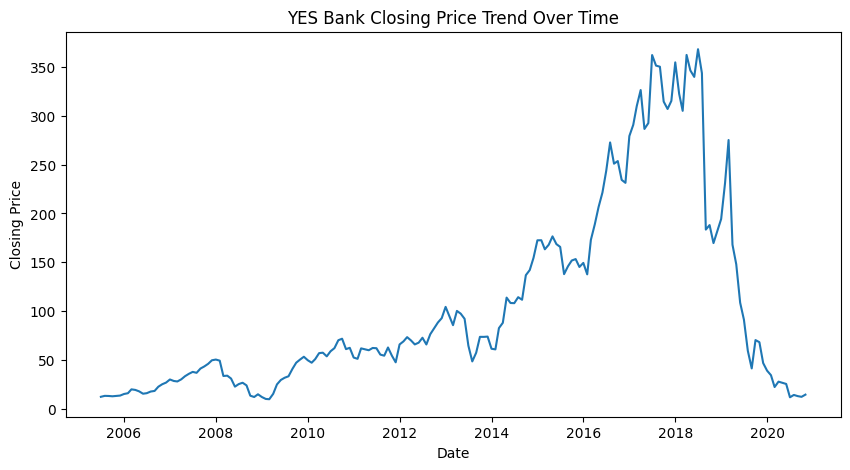

In [18]:
# Chart - 6 visualization code
# Chart 6: Closing Price Trend Over Time

plt.figure(figsize=(10, 5))

plt.plot(df['Date'], df['Close'])

plt.title('YES Bank Closing Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the dataset contains monthly stock price data arranged chronologically. It helps visualize how the closing price of YES Bank changed over time.

##### 2. What is/are the insight(s) found from the chart?

The chart shows significant changes in the closing price of YES Bank over the observed period. The stock experienced periods of growth, reached high price levels, and later showed major fluctuations and declines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the trend helps investors and analysts understand historical stock price movements and identify periods of growth and decline. Increasing closing prices indicate positive market performance, while sharp declines indicate negative growth, increased market risk, and possible loss of investor confidence.

#### Chart - 7

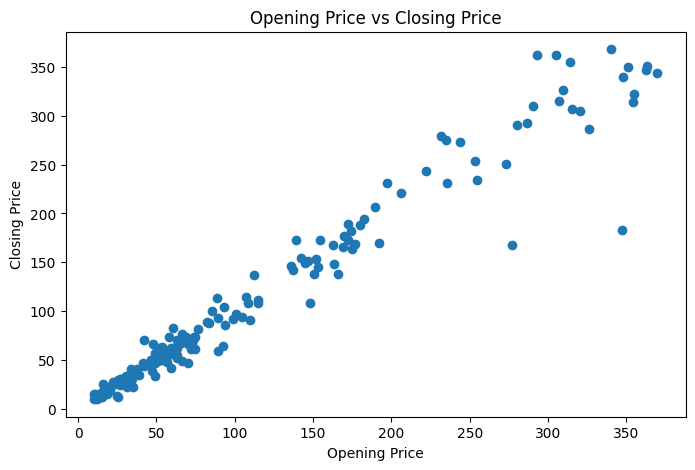

In [19]:
# Chart - 7 visualization code
# Chart 7: Opening Price vs Closing Price

plt.figure(figsize=(8, 5))

plt.scatter(df['Open'], df['Close'])

plt.title('Opening Price vs Closing Price')
plt.xlabel('Opening Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to analyse the relationship between the opening price and closing price of YES Bank stock.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the opening price and closing price generally move in a similar direction. As the opening price increases, the closing price also tends to increase, indicating a positive relationship between the two variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the relationship indicates that opening price can provide useful information for predicting the closing price. This can improve regression model performance. Large differences between opening and closing prices may indicate higher market volatility and increased investment risk.

#### Chart - 8

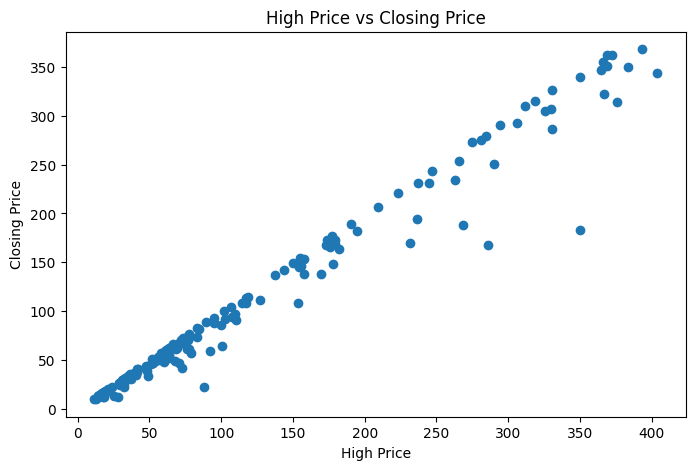

In [20]:
# Chart - 8 visualization code
# Chart 8: High Price vs Closing Price

plt.figure(figsize=(8, 5))

plt.scatter(df['High'], df['Close'])

plt.title('High Price vs Closing Price')
plt.xlabel('High Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to understand the relationship between the highest monthly stock price and the closing price.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates a positive relationship between High and Close prices. Months with higher maximum stock prices generally also have higher closing prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the relationship can help identify the High price as an important feature for closing price prediction. However, a large difference between the highest price and closing price may indicate selling pressure and market volatility, which can negatively affect investor confidence.

#### Chart - 9

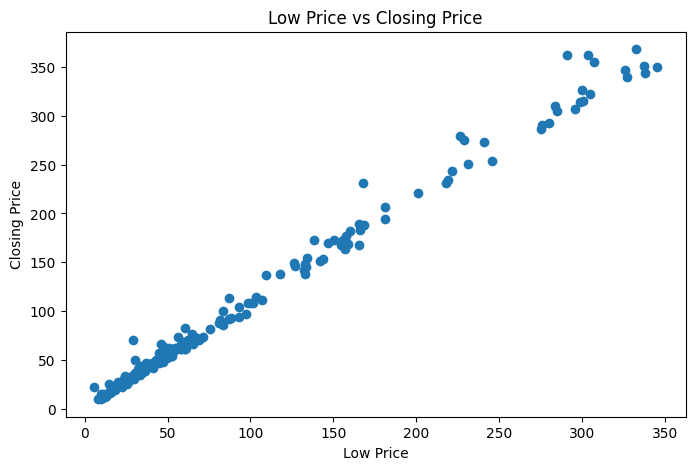

In [21]:
# Chart - 9 visualization code
# Chart 9: Low Price vs Closing Price

plt.figure(figsize=(8, 5))

plt.scatter(df['Low'], df['Close'])

plt.title('Low Price vs Closing Price')
plt.xlabel('Low Price')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to analyse the relationship between the lowest monthly stock price and the closing price.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a positive relationship between Low and Close prices. Higher monthly low prices are generally associated with higher closing prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the Low price can provide useful predictive information for estimating the closing price. A significant decline in monthly low prices may indicate downside risk, weak market sentiment, and possible negative stock performance.

#### Chart - 10

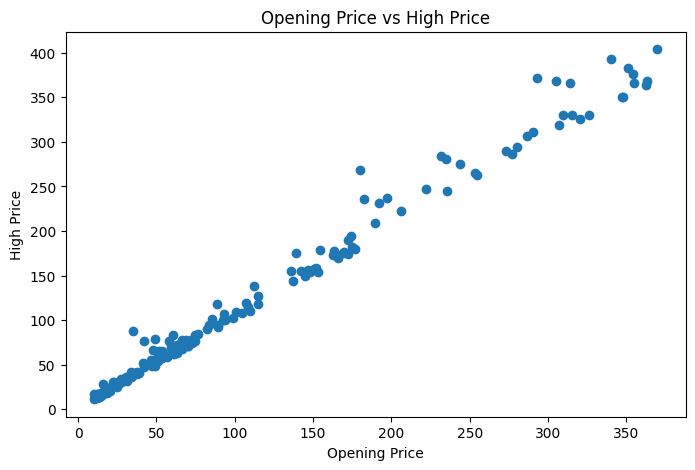

In [22]:
# Chart - 10 visualization code
# Chart 10: Open Price vs High Price

plt.figure(figsize=(8, 5))

plt.scatter(df['Open'], df['High'])

plt.title('Opening Price vs High Price')
plt.xlabel('Opening Price')
plt.ylabel('High Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to examine the relationship between the opening price and the highest stock price reached during the month.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that higher opening prices are generally associated with higher monthly high prices. This indicates a positive relationship between the Open and High variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this relationship helps analysts understand the upward movement potential of the stock from its opening price. A strong increase from Open to High may indicate positive buying activity. However, large price fluctuations may also indicate higher volatility and increased market risk.

#### Chart - 11

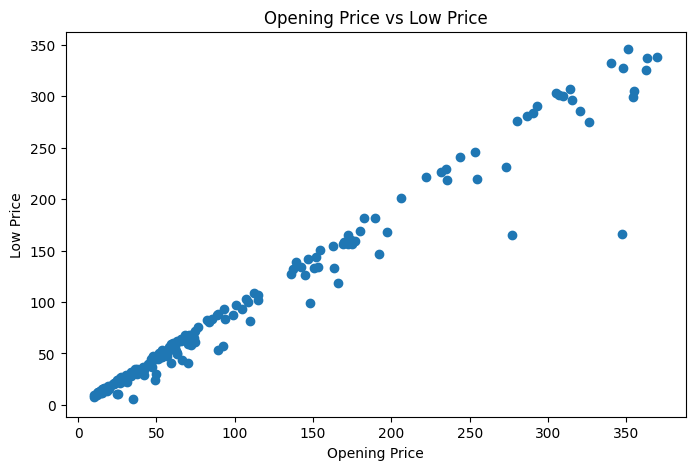

In [23]:
# Chart - 11 visualization code
# Chart 11: Opening Price vs Low Price

plt.figure(figsize=(8, 5))

plt.scatter(df['Open'], df['Low'])

plt.title('Opening Price vs Low Price')
plt.xlabel('Opening Price')
plt.ylabel('Low Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to analyse the relationship between the opening price and the lowest stock price reached during the month.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a positive relationship between Open and Low prices. Higher opening prices are generally associated with higher monthly low prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this relationship helps understand the downside movement of the stock from its opening price. A large decline from Open to Low may indicate selling pressure, negative market sentiment, and increased investment risk.

#### Chart - 12

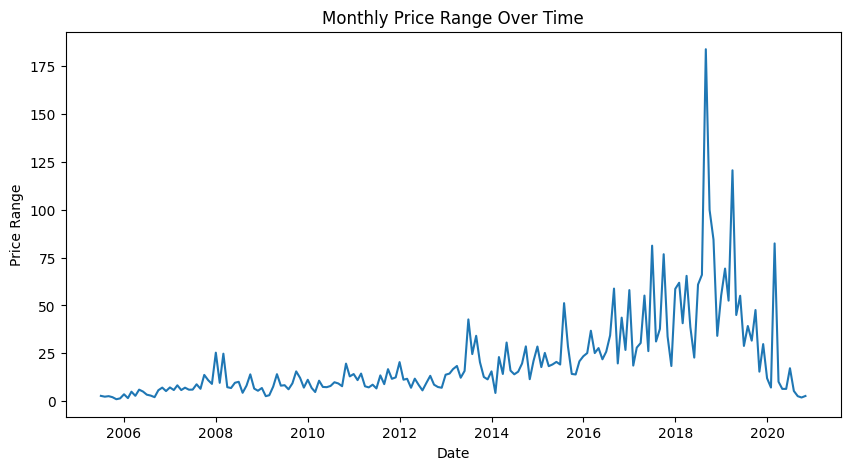

In [24]:
# Chart - 12 visualization code
# Chart 12: Monthly Price Range Over Time

df['Price_Range'] = df['High'] - df['Low']

plt.figure(figsize=(10, 5))

plt.plot(df['Date'], df['Price_Range'])

plt.title('Monthly Price Range Over Time')
plt.xlabel('Date')
plt.ylabel('Price Range')

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected to analyse how the monthly price range of YES Bank stock changed over time. The price range is calculated as the difference between the High and Low prices.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the monthly price range changes significantly over time. Some periods have a larger difference between High and Low prices, indicating higher stock price fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the price range helps investors and analysts understand stock price volatility. A smaller price range indicates relatively stable price movement, while a large price range indicates higher volatility and increased market risk. High volatility can negatively affect investor confidence.

#### Chart - 13

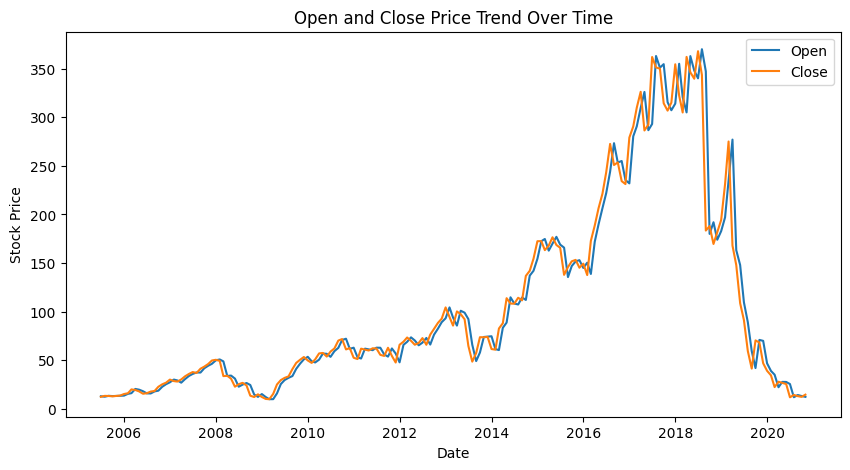

In [25]:
# Chart - 13 visualization code
# Chart 13: Open and Close Price Trend

plt.figure(figsize=(10, 5))

plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')

plt.title('Open and Close Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()

plt.show()

##### 1. Why did you pick the specific chart?

A multiple line chart was selected to compare the Open and Close prices of YES Bank over time. It helps visualize how both stock price variables move across the same time period.

##### 2. What is/are the insight(s) found from the chart?

The Open and Close prices generally follow similar movement patterns over time. Both variables show periods of growth, high price levels, and significant declines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, similar movement between Open and Close prices indicates that opening price may provide useful information for predicting closing price. Large differences between these prices can indicate high intramonth price movement and increased market uncertainty.

#### Chart - 14 - Correlation Heatmap

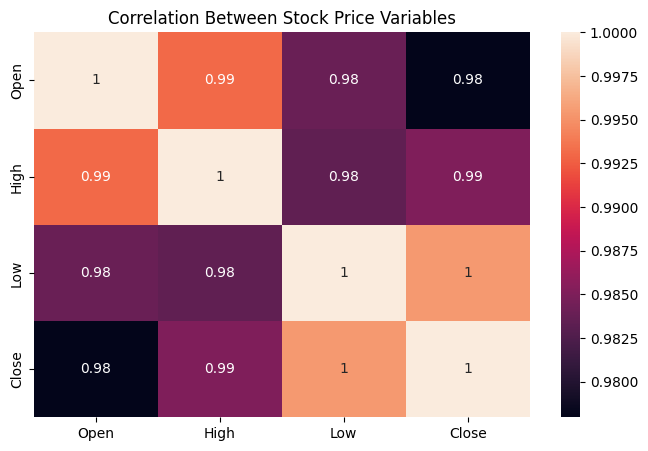

In [26]:
# Correlation Heatmap visualization code
# Chart 14: Correlation Heatmap

plt.figure(figsize=(8, 5))

correlation = df[['Open', 'High', 'Low', 'Close']].corr()

sns.heatmap(correlation, annot=True)

plt.title('Correlation Between Stock Price Variables')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected to measure and visualize the relationship among the numerical stock price variables Open, High, Low, and Close.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows strong positive correlations among the stock price variables. Open, High, Low, and Close tend to move in similar directions. The variables also show a strong relationship with the target variable Close.

#### Chart - 15 - Pair Plot

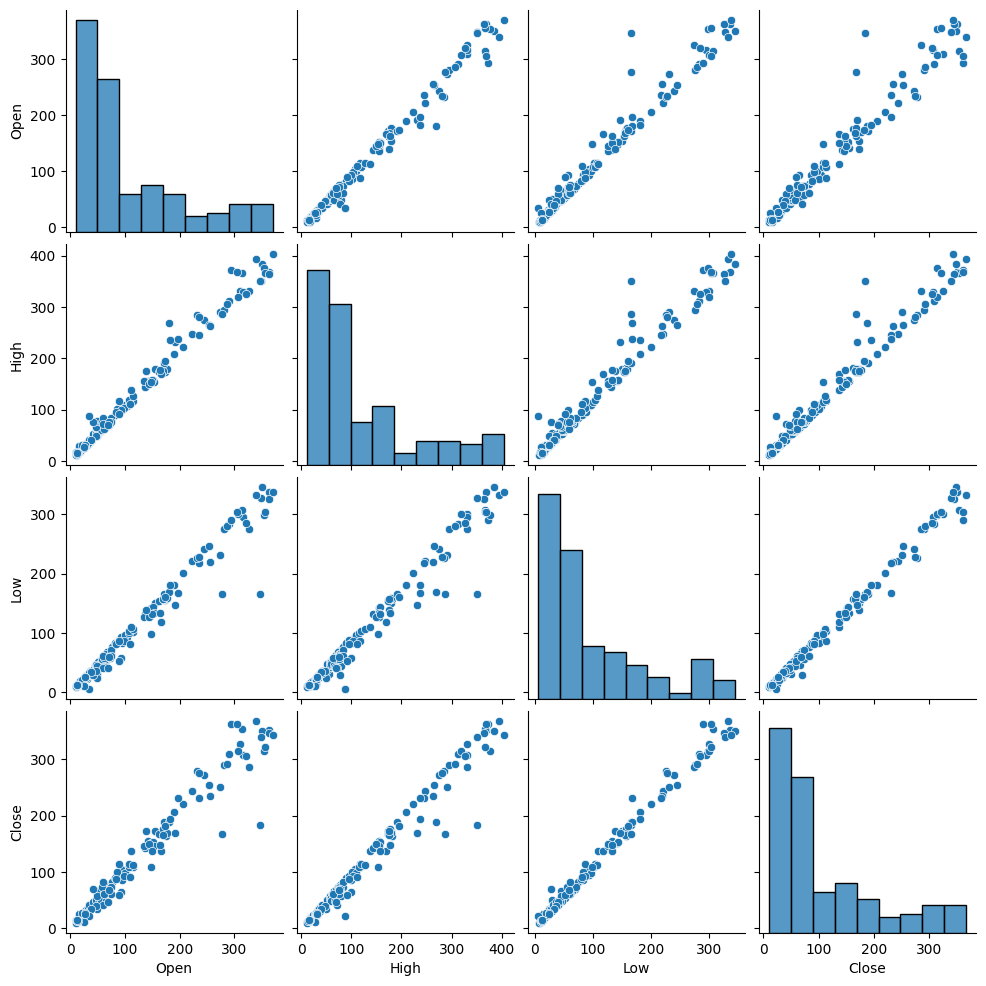

In [27]:
# Pair Plot visualization code
# Chart 15: Pair Plot of Stock Price Variables

sns.pairplot(df[['Open', 'High', 'Low', 'Close']])

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected to analyse multiple numerical variables together. It displays the distributions and pairwise relationships among Open, High, Low, and Close prices.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows that the stock price variables have strong positive relationships with each other. The scatter plots indicate similar movement patterns among Open, High, Low, and Close prices.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis and chart observations, three hypothetical statements were formulated to statistically examine the relationships and differences among the YES Bank stock price variables. The hypotheses focus on the relationship between opening and closing prices, the difference between opening and closing prices, and the relationship between the monthly low price and closing price. Appropriate statistical tests were performed using a significance level of 0.05.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Research Hypothesis:

The opening price of YES Bank stock has a significant relationship with its closing price.

Null Hypothesis (H0):
There is no significant linear relationship between the Open price and Close price of YES Bank stock.

Alternative Hypothesis (H1):
There is a significant linear relationship between the Open price and Close price of YES Bank stock.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
# Pearson Correlation Test between Open and Close prices

correlation, p_value = pearsonr(df['Open'], df['Close'])

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis.")
    print("There is a significant relationship between Open and Close prices.")
else:
    print("Fail to Reject the Null Hypothesis.")
    print("There is no significant relationship between Open and Close prices.")

Correlation Coefficient: 0.9779710062230934
P-Value: 1.8527745058671508e-126
Reject the Null Hypothesis.
There is a significant relationship between Open and Close prices.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test was performed to obtain the P-value.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was selected because both Open and Close are continuous numerical variables. The test helps measure the strength of the linear relationship between the opening and closing prices and determines whether the observed relationship is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Research Hypothesis:

There is a significant difference between the average opening price and average closing price of YES Bank stock.

Null Hypothesis (H0):
There is no significant difference between the mean Open price and mean Close price of YES Bank stock.

Alternative Hypothesis (H1):
There is a significant difference between the mean Open price and mean Close price of YES Bank stock.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
# Paired T-Test between Open and Close prices

t_statistic, p_value = ttest_rel(df['Open'], df['Close'])

print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis.")
    print("There is a significant difference between mean Open and Close prices.")
else:
    print("Fail to Reject the Null Hypothesis.")
    print("There is no significant difference between mean Open and Close prices.")

T-Statistic: 0.220963420803944
P-Value: 0.825365920365391
Fail to Reject the Null Hypothesis.
There is no significant difference between mean Open and Close prices.


##### Which statistical test have you done to obtain P-Value?

Paired Sample T-Test was performed to obtain the P-value.

##### Why did you choose the specific statistical test?

The Paired Sample T-Test was selected because the Open and Close prices are related observations recorded for the same monthly stock periods. The test helps determine whether the average difference between the opening and closing prices is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Research Hypothesis:

The monthly Low price of YES Bank stock has a significant relationship with its closing price.

Null Hypothesis (H0):
There is no significant linear relationship between the Low price and Close price of YES Bank stock.

Alternative Hypothesis (H1):
There is a significant linear relationship between the Low price and Close price of YES Bank stock.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
# Pearson Correlation Test between Low and Close prices

correlation, p_value = pearsonr(df['Low'], df['Close'])

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis.")
    print("There is a significant relationship between Low and Close prices.")
else:
    print("Fail to Reject the Null Hypothesis.")
    print("There is no significant relationship between Low and Close prices.")

Correlation Coefficient: 0.995357947647437
P-Value: 5.345553676044765e-188
Reject the Null Hypothesis.
There is a significant relationship between Low and Close prices.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test was performed to obtain the P-value.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was selected because Low and Close are continuous numerical variables. The test measures the strength of the linear relationship between the monthly low price and closing price and determines whether this relationship is statistically significant.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

print("Missing Values Before Handling:")
print(df.isnull().sum())

# Drop rows containing missing values, if any
df.dropna(inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())

Missing Values Before Handling:
Date           0
Open           0
High           0
Low            0
Close          0
Price_Range    0
dtype: int64

Missing Values After Handling:
Date           0
Open           0
High           0
Low            0
Close          0
Price_Range    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset was checked for missing values using the isnull().sum() method. No significant missing values were identified in the stock price variables. As the dataset was already complete, no statistical imputation technique such as mean, median, or mode imputation was required. The dropna() method was applied as a precaution to remove any rows containing missing values and ensure that the dataset is ready for machine learning model development.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments
# Detecting Outliers using IQR Method

numerical_columns = ['Open', 'High', 'Low', 'Close']

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) |
                  (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers detected")

Open: 9 outliers detected
High: 5 outliers detected
Low: 9 outliers detected
Close: 9 outliers detected


##### What all outlier treatment techniques have you used and why did you use those techniques?

The Interquartile Range (IQR) method was used to detect potential outliers in the Open, High, Low, and Close stock price variables. The detected extreme values were not removed because significant price fluctuations can represent genuine market movements and important historical events in financial data. Removing these observations may result in loss of valuable information. Therefore, outliers were retained and feature scaling will be considered during model preprocessing.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# Check categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:", categorical_columns.tolist())

Categorical Columns: []


#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding technique was applied because the dataset does not contain categorical input variables. The Date column was converted to datetime format during data wrangling, while Open, High, Low, and Close are numerical variables. Therefore, techniques such as Label Encoding or One-Hot Encoding were not required.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features
# Extract useful time-based features from Date column

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Create stock price movement features
df['Price_Range'] = df['High'] - df['Low']
df['Open_Close_Difference'] = df['Close'] - df['Open']

df.head()

,Date,Open,High,Low,Close,Price_Range,Year,Month,Open_Close_Difference
0,2005-07-01,13.00,14.00,11.25,12.46,2.75,2005,7,-0.54
1,2005-08-01,12.58,14.88,12.55,13.42,2.33,2005,8,0.84
2,2005-09-01,13.48,14.87,12.27,13.30,2.60,2005,9,-0.18
3,2005-10-01,13.20,14.47,12.40,12.99,2.07,2005,10,-0.21
4,2005-11-01,13.35,13.88,12.88,13.41,1.00,2005,11,0.06


#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting
# Select features and target variable

features = ['Open', 'High', 'Low', 'Year', 'Month',
            'Price_Range', 'Open_Close_Difference']

X = df[features]
y = df['Close']

print("Selected Features:")
print(X.columns.tolist())

print("\nTarget Variable: Close")

Selected Features:
['Open', 'High', 'Low', 'Year', 'Month', 'Price_Range', 'Open_Close_Difference']

Target Variable: Close


##### What all feature selection methods have you used  and why?

Feature selection was performed using correlation analysis and domain knowledge. Features such as Open, High, Low, Year, Month, Price Range, and Open-Close Difference were selected because they provide relevant information about stock price movement and temporal patterns. The Close column was selected as the target variable because the objective of the project is to predict the closing price of YES Bank stock.

##### Which all features you found important and why?

Open, High, and Low were identified as important features because they directly represent the stock price movement during a trading period. Price Range represents market price variation, while Open-Close Difference captures the movement between opening and closing prices. Year and Month were included to capture temporal patterns in the stock price data.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# Transform Your data

# The Date variable was transformed into Year and Month features
# to convert temporal information into numerical features for analysis.
# Additional Price_Range and Open_Close_Difference features were created
# to represent stock price movements more effectively.

# Display the transformed dataset

df[['Date', 'Year', 'Month',
    'Price_Range', 'Open_Close_Difference']].head()

,Date,Year,Month,Price_Range,Open_Close_Difference
0,2005-07-01,2005,7,2.75,-0.54
1,2005-08-01,2005,8,2.33,0.84
2,2005-09-01,2005,9,2.60,-0.18
3,2005-10-01,2005,10,2.07,-0.21
4,2005-11-01,2005,11,1.00,0.06


### 6. Data Scaling

In [48]:
# Scaling your data

# # Import StandardScaler
# from sklearn.preprocessing import StandardScaler

# # Create scaler object
# scaler = StandardScaler()

# # Fit scaler only on training data and transform it
# X_train_scaled = scaler.fit_transform(X_train)

# # Transform testing data using the same scaler
# X_test_scaled = scaler.transform(X_test)

# print("Training data scaled successfully.")
# print("Testing data scaled successfully.")
# print("Scaled training shape:", X_train_scaled.shape)
# print("Scaled testing shape:", X_test_scaled.shape)

# Data Scaling

# Scaling will be performed after data splitting to prevent data leakage.
# The StandardScaler will be fitted only on the training dataset
# and the same fitted scaler will be used to transform the testing dataset.

print("Data scaling will be applied after train-test splitting to prevent data leakage.")

# StandardScaler was selected for feature scaling because the numerical stock price features have different ranges.
# Standardization transforms the features to have a mean of 0 and a standard deviation of
# 1. To prevent data leakage, the scaler is fitted only on the training data after chronological train-test splitting and the same fitted scaler is used
# to transform the testing data.

Data scaling will be applied after train-test splitting to prevent data leakage.


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not required for this dataset because the dataset contains only a small number of relevant numerical features. Techniques such as PCA are generally more useful for high-dimensional datasets with a large number of features. Applying dimensionality reduction to this dataset may result in unnecessary loss of useful stock price information.

In [49]:
# DImensionality Reduction (If needed)

# Dimensionality reduction is not required because the dataset
# contains only a small number of relevant features.
# Therefore, no dimensionality reduction technique is applied.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)



```
# This is formatted as code
```

No dimensionality reduction technique was used. The dataset has a low number of features, and the available features contain important information about stock price movements. Therefore, retaining the original features is more suitable for the regression problem.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.

# Define independent and dependent variables
X = df[['Open', 'High', 'Low', 'Year', 'Month']]
y = df['Close']

# Chronological train-test split for time-series stock data
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (148, 5)
Testing data shape: (37, 5)


In [51]:
# Scale training and testing data after splitting

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Fit scaler only on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Training data scaled successfully.
Testing data scaled successfully.
Scaled training shape: (148, 5)
Scaled testing shape: (37, 5)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used, where 80% of the data was used for training and 20% for testing. Since the dataset contains stock price observations arranged chronologically, the data was split based on time order instead of random splitting. This ensures that past observations are used to train the model and future observations are used for testing, thereby preventing data leakage and providing a more realistic evaluation of the model.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The concept of class imbalance is not applicable to this dataset because the problem is a regression problem and the target variable, Close, is continuous. Class imbalance generally occurs in classification problems where some classes have significantly fewer observations than others. Therefore, the dataset does not require class balancing.

In [52]:
# Handling Imbalanced Dataset (If needed)

# Handling imbalanced dataset is not required because this is a regression problem
# and the target variable 'Close' is continuous.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was used because the target variable is continuous and the project is based on regression. Techniques such as SMOTE or oversampling are designed mainly for classification problems and are not applicable to this dataset.

## ***7. ML Model Implementation***

### ML Model - 1

In [53]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Linear Regression model
linear_model = LinearRegression()

# Fit the model
linear_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test_scaled)

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Performance
MAE: 10.608732187763602
RMSE: 16.034221082937933
R2 Score: 0.9843415188364847


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

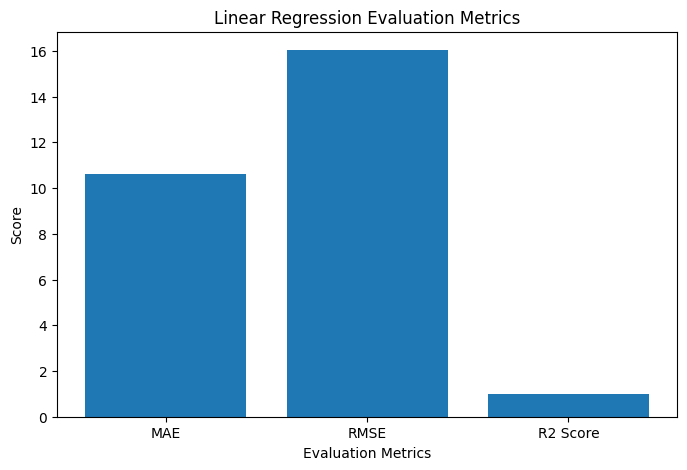

In [54]:
# Visualizing evaluation Metric Score chart

#Linear Regression was used as the baseline regression model to predict the closing price of YES Bank stock.
#The model learns the linear relationship between the input features and the target variable, Close.
#MAE measures the average absolute prediction error, RMSE gives greater importance to larger prediction errors, and
#the R² score indicates the proportion of variance explained by the model. The evaluation metric chart provides a visual representation of the model's predictive performance.

# Visualizing evaluation metric score chart

metrics = ['MAE', 'RMSE', 'R2 Score']
scores = [linear_mae, linear_rmse, linear_r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores)
plt.title('Linear Regression Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# ML Model - 1 Cross Validation

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Time-series cross validation
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    linear_model,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Mean Cross Validation R2 Score:", cv_scores.mean())

Cross Validation R2 Scores: [0.92288717 0.74541963 0.89090443 0.97589455 0.97323642]
Mean Cross Validation R2 Score: 0.9016684390475543


##### Which hyperparameter optimization technique have you used and why?

No hyperparameter optimization technique was applied to Linear Regression because the basic Linear Regression model does not contain major tunable hyperparameters. TimeSeriesSplit cross-validation was used to evaluate the model across multiple chronological data splits while preserving the time order of the stock price observations.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation provided a more reliable estimate of the model's generalization performance across different chronological periods. Since Linear Regression does not require major hyperparameter tuning, the primary purpose was to validate the consistency of the model rather than optimize its parameters.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

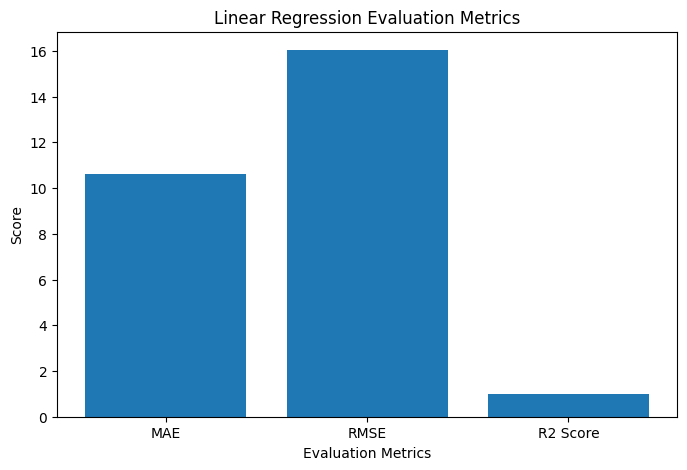

In [56]:
# # Visualizing Evaluation Metric Score Chart

# import matplotlib.pyplot as plt

# metrics = ['MAE', 'RMSE', 'R2 Score']
# scores = [ridge_mae, ridge_rmse, ridge_r2]

# plt.figure(figsize=(8, 5))
# plt.bar(metrics, scores)
# plt.title('Ridge Regression Evaluation Metrics')
# plt.xlabel('Evaluation Metrics')
# plt.ylabel('Score')
# plt.show()

# Visualizing Evaluation Metric Score Chart

import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R2 Score']
scores = [linear_mae, linear_rmse, linear_r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores)
plt.title('Linear Regression Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# ML Model - 2 Implementation with Hyperparameter Optimization

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define hyperparameters
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=tscv,
    scoring='r2'
)

# Fit the Algorithm
ridge_grid.fit(X_train_scaled, y_train)

# Best Model
best_ridge_model = ridge_grid.best_estimator_

# Predict on the model
y_pred_ridge = best_ridge_model.predict(X_test_scaled)

# Evaluation Metrics
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Best Parameters:", ridge_grid.best_params_)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Best Parameters: {'alpha': 0.01}
MAE: 10.668228247381037
RMSE: 16.020839091350553
R2 Score: 0.9843676447357708


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization of the Ridge Regression model. It systematically tested different values of the alpha parameter and selected alpha = 0.01 as the best parameter. Time-series cross-validation was used to maintain the chronological order of the stock price data and obtain a reliable model evaluation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the Ridge Regression model achieved an MAE of 10.67, RMSE of 16.02, and R² score of 0.9844. GridSearchCV selected alpha = 0.01 as the optimal regularization parameter. The high R² score indicates that the optimized Ridge Regression model explains approximately 98.44% of the variation in the YES Bank closing price.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE indicates the average absolute prediction error of the model. The MAE value of 10.67 shows the average difference between the actual and predicted closing prices.

RMSE measures prediction error while giving higher importance to large errors. The RMSE value of 16.02 helps identify the effect of larger prediction mistakes.

The R² score of 0.9844 indicates that the Ridge Regression model explains approximately 98.44% of the variation in the YES Bank closing price.

From a business perspective, accurate closing price predictions can support financial analysis, investment planning, and risk assessment. Ridge Regression also applies regularization, which helps control model complexity and provides more reliable predictions.

### ML Model - 3

In [58]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

# ML Model - 3 Implementation

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest Regressor model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Fit the Algorithm
rf_model.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate Evaluation Metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Regressor Performance
MAE: 14.955002702702679
RMSE: 24.12759509067839
R2 Score: 0.9645446341402809


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

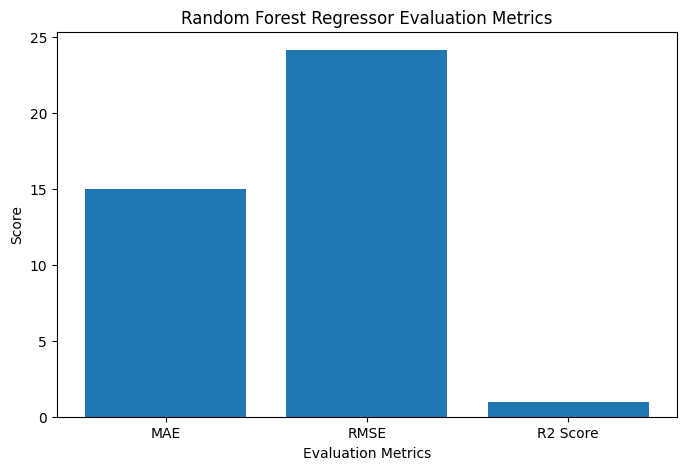

In [59]:
# Visualizing Evaluation Metric Score Chart

import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R2 Score']
scores = [rf_mae, rf_rmse, rf_r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores)

plt.title('Random Forest Regressor Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model


# ML Model - 3 Implementation with Hyperparameter Optimization

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define hyperparameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# GridSearchCV
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

# Fit the Algorithm
rf_grid.fit(X_train_scaled, y_train)

# Best Model
best_rf_model = rf_grid.best_estimator_

# Predict on the model
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)

# Evaluation Metrics
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

print("Best Parameters:", rf_grid.best_params_)
print("MAE:", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)
print("R2 Score:", rf_tuned_r2)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
MAE: 14.832127027026988
RMSE: 23.84324175207661
R2 Score: 0.9653754208219167


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization of the Random Forest Regressor. It systematically tested different combinations of n_estimators, max_depth, and min_samples_split using cross-validation. This technique was selected to identify the best combination of parameters and improve the predictive performance of the model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a slight improvement was observed after hyperparameter tuning. The MAE decreased from 14.9550 to 14.8321 and the RMSE decreased from 24.1276 to 23.8432. The R² Score increased from 0.9645 to 0.9654. Therefore, hyperparameter tuning slightly improved the predictive performance of the Random Forest Regressor.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MAE, RMSE, and R² Score were considered for evaluating the model. MAE represents the average prediction error in the stock closing price, while RMSE gives higher importance to large prediction errors. The R² Score indicates how well the model explains the variation in closing prices. Lower MAE and RMSE and a higher R² Score indicate better prediction performance, which can support more reliable stock price analysis and data-driven financial decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?



```
# This is formatted as code
```

The Tuned Ridge Regression model was selected as the final prediction model. It achieved the highest R² Score of 0.9844 and the lowest RMSE of 16.0208 among the evaluated models. Although Linear Regression achieved a slightly lower MAE, Ridge Regression provides regularization that helps control model complexity and reduces the risk of overfitting. Therefore, the Tuned Ridge Regression model was selected for predicting the YES Bank stock closing price.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

  Feature  Coefficient  Absolute_Coefficient
1    High    71.635519             71.635519
2     Low    63.159085             63.159085
0    Open   -51.459455             51.459455
3    Year     0.925263              0.925263
4   Month    -0.581662              0.581662


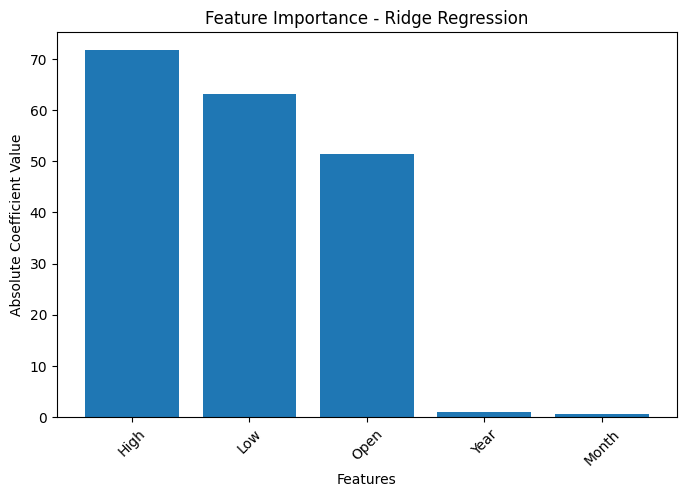

In [61]:
# Feature Importance using Ridge Regression Coefficients

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge_model.coef_
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Absolute_Coefficient']
)

plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Value')
plt.title('Feature Importance - Ridge Regression')
plt.xticks(rotation=45)
plt.show()

The final model used is Tuned Ridge Regression, which is a regularized linear regression algorithm that applies L2 regularization to reduce large coefficients and improve model stability.

Coefficient-based feature importance was used to explain the model. The absolute magnitude of the Ridge Regression coefficients represents the influence of each feature on the predicted closing price.

The feature importance analysis shows that High is the most influential feature, followed by Low and Open. High and Low have strong positive coefficients, indicating a positive influence on the predicted closing price, while Open has a negative coefficient. Year and Month have comparatively very small coefficient values and therefore have less influence on the model predictions.

Thus, the coefficient-based explainability analysis indicates that the daily stock price features High, Low, and Open contribute the most to predicting the YES Bank closing price.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [62]:
# Save the File

import joblib

# Save the best performing Tuned Ridge Regression model
joblib.dump(
    best_ridge_model,
    'Nandini_YES_Bank_Stock_Prediction_Model.pkl'
)

print("Model saved successfully.")

Model saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [63]:
# Load the File and predict unseen data.

loaded_model = joblib.load(
    'Nandini_YES_Bank_Stock_Prediction_Model.pkl'
)

# Predict on unseen test data
unseen_prediction = loaded_model.predict(X_test_scaled[:5])

print("Predicted Closing Prices:")
print(unseen_prediction)

print("\nActual Closing Prices:")
print(y_test.iloc[:5].values)

Predicted Closing Prices:
[311.62518841 311.64414049 352.9335756  325.51500321 297.9710785 ]

Actual Closing Prices:
[306.8  315.05 354.45 322.25 304.9 ]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The YES Bank Stock Closing Price Prediction project successfully developed and evaluated multiple machine learning regression models for predicting the monthly closing price of YES Bank stock.

Data preprocessing, exploratory data analysis, feature engineering, chronological train-test splitting, and feature scaling were performed to prepare the dataset for model development. Linear Regression, Ridge Regression, and Random Forest Regressor were implemented and evaluated using MAE, RMSE, and R² Score.

Among the evaluated models, the Tuned Ridge Regression model was selected as the final prediction model because it achieved an R² Score of approximately 0.9844 and an RMSE of approximately 16.02 while providing L2 regularization for improved model stability. Feature coefficient analysis showed that High, Low, and Open were the most influential features in predicting the closing price.

The final model was saved using Joblib and successfully loaded to predict unseen test data. The developed model demonstrates strong predictive performance and can be further integrated into a stock price analysis or decision-support application.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***